# Creating the Graph to make the new correlation matrix

In [ ]:
from tara_preprocessing import full_preprocessing,make_rbf_correlation_matrix,get_just_ecog_data,get_electrode_normalized_loc,make_patient_correlation_matrix
from pathlib import Path
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from itertools import combinations
import networkx as nx

data_root = Path("/Users/noahwanless/Desktop/Spring2026/M467/faces_basic/data")
registered_dir = Path("../SuperEeg-M467-project/registered_outputs")
ecogs = get_just_ecog_data(registered_dir,data_root)
xyz = get_electrode_normalized_loc(registered_dir)

xyz_clean, mapping_clean, kept_global_indices, cleaned = full_preprocessing(ecogs,xyz)

patient_corr_mat = make_patient_correlation_matrix(xyz_clean,cleaned,mapping_clean)

[PosixPath('../SuperEeg-M467-project/registered_outputs/aa_xslocs_registered_mm.npy'), PosixPath('../SuperEeg-M467-project/registered_outputs/ap_xslocs_registered_mm.npy'), PosixPath('../SuperEeg-M467-project/registered_outputs/ca_xslocs_registered_mm.npy'), PosixPath('../SuperEeg-M467-project/registered_outputs/de_xslocs_registered_mm.npy'), PosixPath('../SuperEeg-M467-project/registered_outputs/fp_xslocs_registered_mm.npy'), PosixPath('../SuperEeg-M467-project/registered_outputs/ha_xslocs_registered_mm.npy'), PosixPath('../SuperEeg-M467-project/registered_outputs/ja_xslocs_registered_mm.npy'), PosixPath('../SuperEeg-M467-project/registered_outputs/jm_xslocs_registered_mm.npy'), PosixPath('../SuperEeg-M467-project/registered_outputs/jt_xslocs_registered_mm.npy'), PosixPath('../SuperEeg-M467-project/registered_outputs/mv_xslocs_registered_mm.npy'), PosixPath('../SuperEeg-M467-project/registered_outputs/rn_xslocs_registered_mm.npy'), PosixPath('../SuperEeg-M467-project/registered_output

# Graph of the nodes on the brain

In [36]:
from sklearn.neighbors import NearestNeighbors
from tqdm import tqdm
k = 10
num_nodes = 649
neigh = NearestNeighbors(n_neighbors=k).fit(xyz_clean)
indicesofneigh = neigh.kneighbors()[1] #gets the indices of the 10 (or k) neighbors of each node

# turn indices lists into pairwiase combos
all_edges = []
iter = 0
for indexs in indicesofneigh:
    #temp = []
    for num in indexs:
        all_edges.append((iter,num))
    iter += 1
    
G = nx.Graph()
nodes = np.arange(num_nodes)
G.add_nodes_from(nodes)
G.add_edges_from(all_edges)

Glaplacian = nx.linalg.laplacian_matrix(G).toarray() #gets the laplacian of the bain graph for use to use

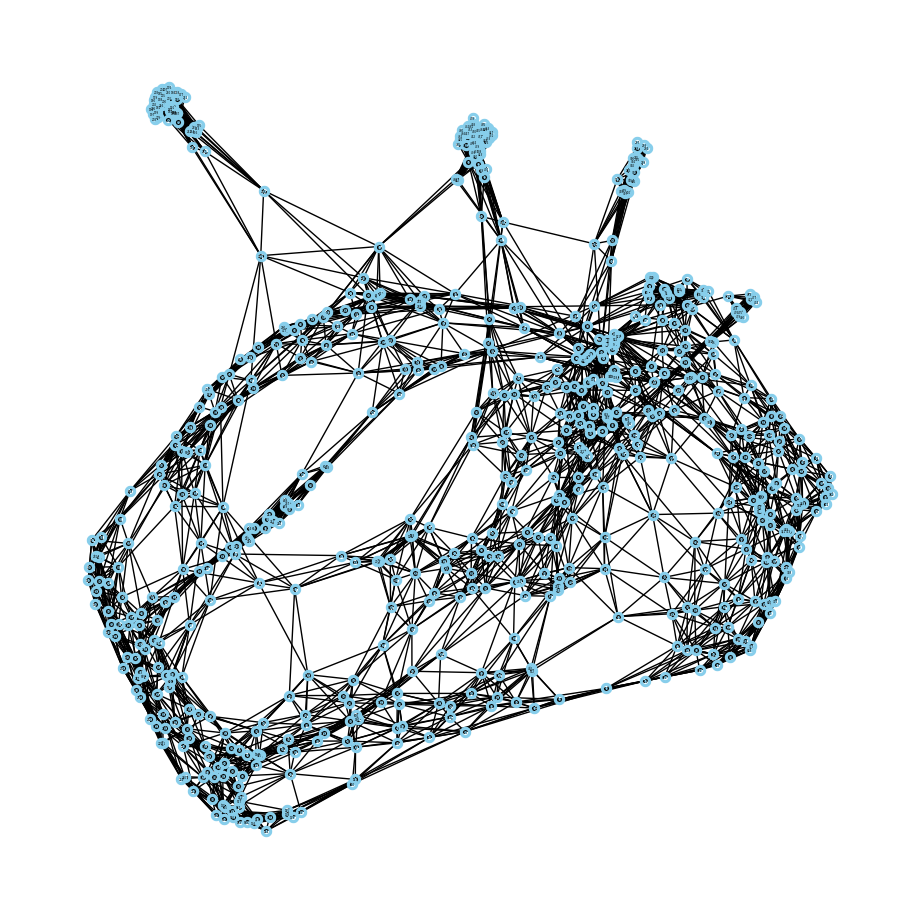

In [4]:
plt.figure(figsize=(9, 9))
pos = nx.spring_layout(G) # Position nodes using Fruchterman-Reingold force-directed algorithm
nx.draw(G, pos, with_labels=True, node_color='skyblue', node_size=5, edge_color='k', linewidths=6, font_size=2)
plt.show()

# PyTorch implementaion of our objective function

See notes, but U will have a shape (649,r) which we will iterate through by taking chunks of size (n,r) where n is the number of observed electrodes for that patient, this means this value changes for each paitent but will sum to 649 or whatever the total number of nodes is.

generally increasing r will increase the approximation and complexity of U, however it comes at the cost of computation time and complexity

In [ ]:
import torch

patient_node_num = []# this is how many nodes each paitent has
r = 200 #This is the rank of the approximation, or the number of columns of U
L = torch.tensor(Glaplacian,dtype=torch.float32,requires_grad=True)
U = torch.rand((649,r),requires_grad=True)
C = [] #this is your list of correlation matrixs
for corr in patient_corr_mat:
    C.append(torch.tensor(np.array(corr),requires_grad=True))
    patient_node_num.append(corr.shape[0])


def object_func(C,U,L):
    sum = torch.tensor(0,dtype=torch.float32,requires_grad=True)
    iter = 0
    for i in range(14):
        c = C[i] #each patient correlation matrix
        num_nodes = patient_node_num[i]
        u = U[iter:iter+num_nodes,:] #all columns of rows iter+num of nodes + 1 
        sum = sum + (torch.linalg.norm((u@u.T - c),ord='fro'))**2 + 2*torch.trace(U.T@L@U)
        iter += num_nodes
    return sum
object_func(C,U,L)

tensor(93404730.9547, dtype=torch.float64, grad_fn=<AddBackward0>)

### Training and evaluation

In [45]:
optimizer = torch.optim.Adam([U], lr=0.01) 
for step in tqdm(range(1000)):
    optimizer.zero_grad()
    z = object_func(C,U,L) #this is our loss function
    z.backward()
    optimizer.step()

100%|██████████| 1000/1000 [00:20<00:00, 47.92it/s]


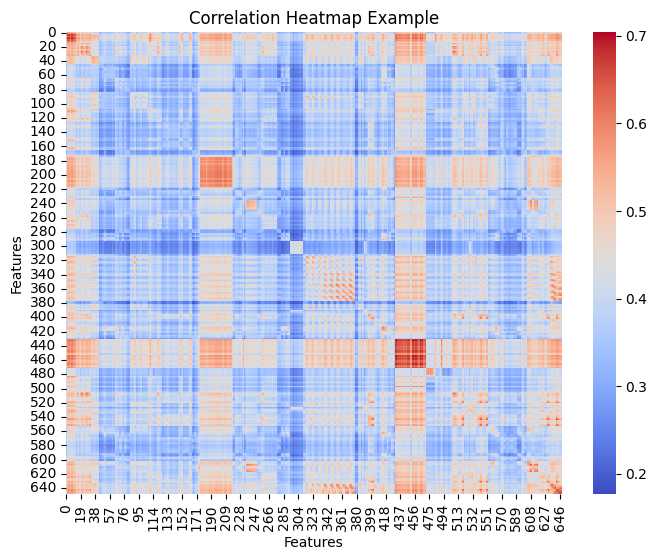

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(U.detach()@U.detach().T, cmap='coolwarm') 
plt.title('Correlation Heatmap Example')
plt.xlabel('Features')
plt.ylabel('Features')
plt.show()